<a href="https://colab.research.google.com/github/sabdashy/Matkul_MachineLearning/blob/tugas/Notebook/Tugas/Tugas13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install kaggle

In [2]:
kaggle = '/content/kaggle.json'

In [3]:
!mkdir -p ~/.kaggle
!cp {kaggle} ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [4]:
!kaggle datasets download -d olafkrastovski/handwritten-digits-0-9

Dataset URL: https://www.kaggle.com/datasets/olafkrastovski/handwritten-digits-0-9
License(s): CC0-1.0
handwritten-digits-0-9.zip: Skipping, found more recently modified local copy (use --force to force download)


In [5]:
from zipfile import ZipFile
import os
file_name = 'handwritten-digits-0-9.zip'

extract_folder = 'dataset'
os.makedirs(extract_folder, exist_ok=True)

with ZipFile(file_name, 'r') as zip:
  zip.extractall(extract_folder)
  print('done')

done


In [6]:
# Operasi numerik
import numpy as np

# OpenCV untuk membaca gambar
import cv2

# Visualisasi
import matplotlib.pyplot as plt
import seaborn as sns

# ANN dari TensorFlow / Keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

# Evaluasi model
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report



In [7]:
!pip install opencv-python

In [8]:
print(cv2.__version__)


4.12.0


In [9]:
!ls

dataset  handwritten-digits-0-9.zip  kaggle.json  sample_data


In [10]:
# Path utama dataset
DATASET_PATH = "/content/dataset"

# List untuk menyimpan citra dan label
X = []
y = []


In [11]:
# Loop setiap kelas digit (0–9)
for label in range(10):
    folder_path = os.path.join(DATASET_PATH, str(label))

    # Loop setiap file gambar di dalam folder
    for img_name in os.listdir(folder_path):
        img_path = os.path.join(folder_path, img_name)

        # Membaca gambar dalam mode grayscale
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        # Resize gambar ke ukuran 28x28 (standar MNIST)
        img = cv2.resize(img, (28, 28))

        # Menyimpan data gambar dan label
        X.append(img)
        y.append(label)


In [12]:
# Mengubah list menjadi array numpy
X = np.array(X)
y = np.array(y)

# Menampilkan bentuk data
print("Shape X:", X.shape)
print("Shape y:", y.shape)


Shape X: (21555, 28, 28)
Shape y: (21555,)


In [13]:
# Normalisasi pixel (0–255 menjadi 0–1)
X = X / 255.0

In [14]:
# One-hot encoding label (0–9)
y = to_categorical(y, num_classes=10)

In [15]:
# Membagi data menjadi train dan test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [16]:
# Membuat model ANN menggunakan Sequential
model = Sequential()

# Flatten: 28x28 → 784 vektor
model.add(Flatten(input_shape=(28, 28)))

# Hidden layer pertama
model.add(Dense(512, activation='relu'))

# Hidden layer kedua
model.add(Dense(256, activation='relu'))

# Output layer (10 kelas digit)
model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [17]:
# Compile model
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [18]:
# Menampilkan struktur model
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 535,818 (2.04 MB)

 Trainable params: 535,818 (2.04 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
# Melatih model menggunakan data training
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=128,
    validation_split=0.1,
    verbose=1
)

Epoch 1/20
122/122 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.1192 - loss: 2.4099 - val_accuracy: 0.1362 - val_loss: 2.2268
Epoch 2/20
122/122 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.2234 - loss: 2.1650 - val_accuracy: 0.2719 - val_loss: 2.0483
Epoch 3/20
122/122 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.2955 - loss: 1.9823 - val_accuracy: 0.3130 - val_loss: 1.9357
Epoch 4/20
122/122 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.3643 - loss: 1.8452 - val_accuracy: 0.4006 - val_loss: 1.7999
Epoch 5/20
122/122 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.3969 - loss: 1.7859 - val_accuracy: 0.4041 - val_loss: 1.7488
Epoch 6/20
122/122 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.4241 - loss: 1.7301 - val_accuracy: 0.4388 - val_loss: 1.6560
Epoch 7/20
122/122 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.4635 - loss: 1.6345 - val_accuracy: 0.4562 - val_loss: 1.6403
Epoch 8/20
122/122 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.4704 - loss: 1.6198 - val_accu

In [20]:
# Evaluasi menggunakan data testing
test_loss, test_acc = model.evaluate(X_test, y_test)

print("Test Accuracy :", test_acc)
print("Test Loss     :", test_loss)


135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.6192 - loss: 1.2073
Test Accuracy : 0.616794228553772
Test Loss     : 1.191644310951233


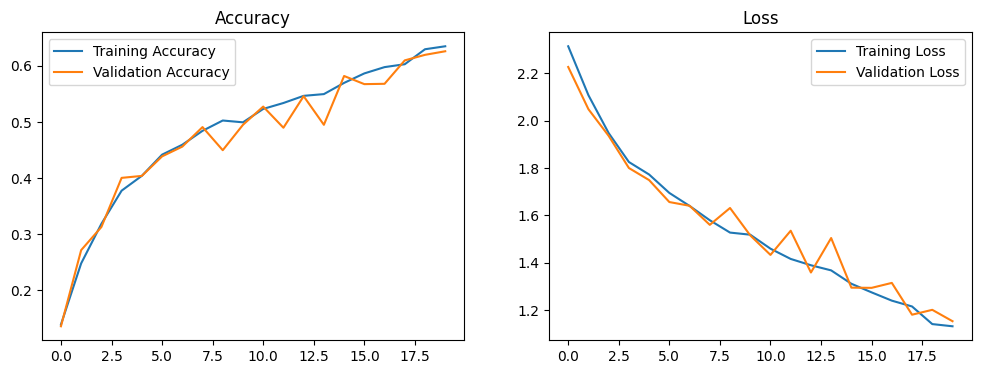

In [21]:
# Membuat grafik akurasi dan loss
plt.figure(figsize=(12,4))

# Grafik akurasi
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.legend()

# Grafik loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.legend()

plt.show()

In [22]:
# Prediksi data testing
y_pred = model.predict(X_test)

# Mengambil kelas dengan probabilitas tertinggi
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

135/135 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


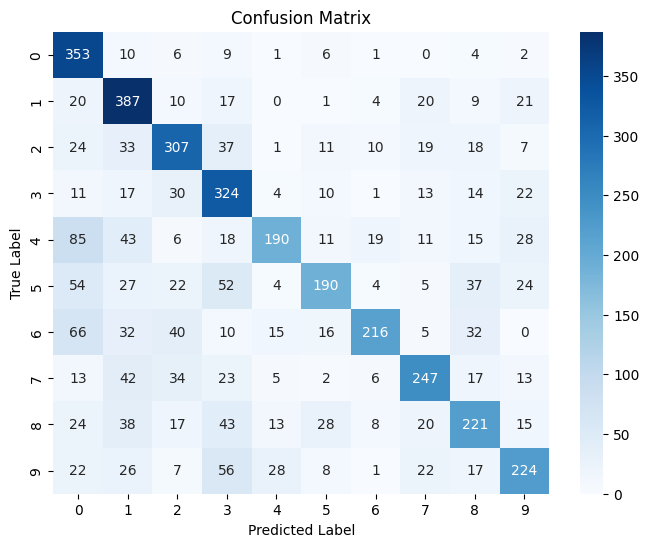

In [23]:
# Membuat confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

# Visualisasi confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [24]:
# Menampilkan classification report
print(classification_report(y_true, y_pred_classes))

              precision    recall  f1-score   support

           0       0.53      0.90      0.66       392
           1       0.59      0.79      0.68       489
           2       0.64      0.66      0.65       467
           3       0.55      0.73      0.63       446
           4       0.73      0.45      0.55       426
           5       0.67      0.45      0.54       419
           6       0.80      0.50      0.62       432
           7       0.68      0.61      0.65       402
           8       0.58      0.52      0.55       427
           9       0.63      0.55      0.58       411

    accuracy                           0.62      4311
   macro avg       0.64      0.62      0.61      4311
weighted avg       0.64      0.62      0.61      4311

